In [6]:
import pandas as pd
path = "Ice_cream_selling_data.csv"
df = pd.read_csv(path)
print(df.head())

   Temperature (°C)  Ice Cream Sales (units)
0         -4.662263                41.842986
1         -4.316559                34.661120
2         -4.213985                39.383001
3         -3.949661                37.539845
4         -3.578554                32.284531


In [7]:
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

<function matplotlib.pyplot.show(close=None, block=None)>

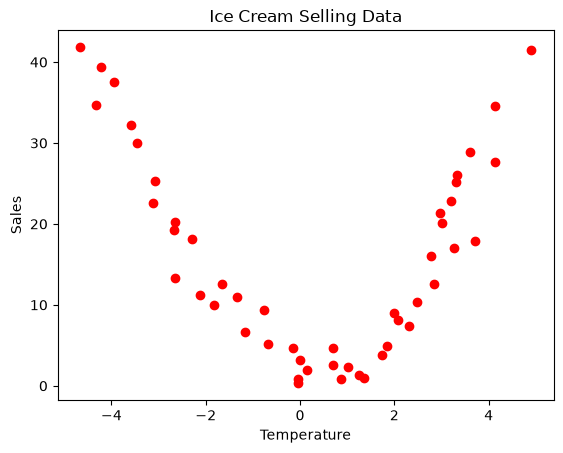

In [8]:
import matplotlib.pyplot as halo
halo.scatter(X, y, color = 'red')
halo.title('Ice Cream Selling Data')
halo.xlabel('Temperature')
halo.ylabel('Sales')
halo.show

Text(0.5, 1.0, 'Linear Regression')

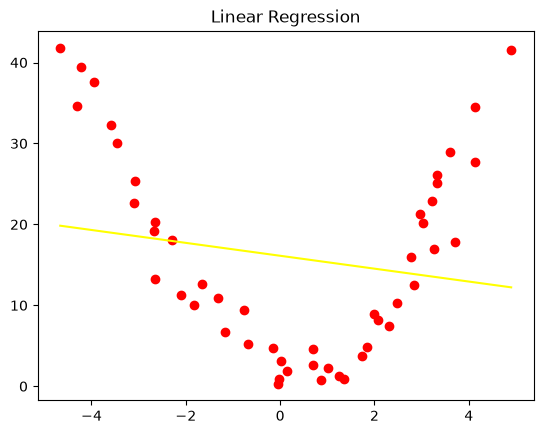

In [9]:
from sklearn.linear_model import LinearRegression
linear_model = LinearRegression()
linear_model.fit(X, y)
halo.scatter(X, y,  color = 'red')
halo.plot(X, linear_model.predict(X), color = 'yellow')
halo.title('Linear Regression')

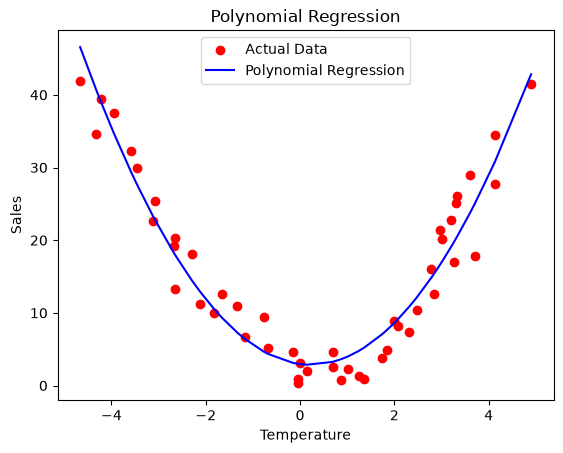

In [10]:
from sklearn.preprocessing import PolynomialFeatures

# Buat Polynomial Features
poly_reg = PolynomialFeatures(degree=2)
X_poly = poly_reg.fit_transform(X)

# Buat Model Linear Regression
linear_model2 = LinearRegression()
linear_model2.fit(X_poly, y) # Latih model dengan data polynomial

# Gunakan Predict() untuk mendapatkan y_pred_poly
y_pred_poly = linear_model2.predict(X_poly)

# Plot Polynomial Regression
halo.scatter(X, y, color='red', label="Actual Data")
halo.plot(X, y_pred_poly, color='blue', label="Polynomial Regression")
halo.title('Polynomial Regression')
halo.xlabel('Temperature')
halo.ylabel('Sales')
halo.legend()
halo.show()

In [11]:
print('Intercept: ', linear_model2.intercept_)
print('Coefficient: ', linear_model2.coef_)

print('Equation: y = ', linear_model2.intercept_, '+', linear_model2.coef_[1], 'x +', )
print('Equation: y = ', linear_model2.intercept_, '+', linear_model2.coef_[1], 'x + x', linear_model2.coef_[2], 'x^2')

Intercept:  2.951774157993448
Coefficient:  [ 0.         -0.82468167  1.82952623]
Equation: y =  2.951774157993448 + -0.8246816702106476 x +
Equation: y =  2.951774157993448 + -0.8246816702106476 x + x 1.8295262296702082 x^2


In [12]:
dataset = pd.read_csv('manufacturing.csv')
print(dataset.head())

   Temperature (°C)  Pressure (kPa)  Temperature x Pressure  \
0        209.762701        8.050855             1688.769167   
1        243.037873       15.812068             3842.931469   
2        220.552675        7.843130             1729.823314   
3        208.976637       23.786089             4970.736918   
4        184.730960       15.797812             2918.345014   

   Material Fusion Metric  Material Transformation Metric  Quality Rating  
0            44522.217074                    9.229576e+06       99.999971  
1            63020.764997                    1.435537e+07       99.985703  
2            49125.950249                    1.072839e+07       99.999758  
3            57128.881547                    9.125702e+06       99.999975  
4            38068.201283                    6.303792e+06      100.000000  


In [13]:
X = dataset.iloc[:, 2:5].values
y = dataset.iloc[:, 5].values
X

array([[1.68876917e+03, 4.45222171e+04, 9.22957596e+06],
       [3.84293147e+03, 6.30207650e+04, 1.43553672e+07],
       [1.72982331e+03, 4.91259502e+04, 1.07283887e+07],
       ...,
       [3.95630467e+03, 6.26576910e+04, 1.40595745e+07],
       [4.97723476e+03, 5.71959855e+04, 9.13403620e+06],
       [3.97489712e+03, 4.10923929e+04, 4.35891253e+06]], shape=(3957, 3))

In [14]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

In [15]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

poly_reg = PolynomialFeatures(degree=2)
X_train_poly = poly_reg.fit_transform(X_train)
X_test_poly = poly_reg.transform(X_test)

linear_model2 = LinearRegression()
linear_model2.fit(X_train_poly, y_train)

y_pred = linear_model2.predict(X_test_poly)


In [16]:
from sklearn.metrics import r2_score
score=r2_score(y_test, y_pred)
score

0.6785135844656534

========================================================
Tugas
========================================================

In [25]:
from sklearn.preprocessing import PolynomialFeatures

In [26]:
degrees = [1, 3, 5]

In [28]:
for d in degrees:
    poly_reg = PolynomialFeatures(degree=d)
    X_train_poly = poly_reg.fit_transform(X_train)
    X_test_poly = poly_reg.transform(X_test)

    lin_model = LinearRegression()
    lin_model.fit(X_train_poly, y_train)

    y_pred = lin_model.predict(X_test_poly)
    score = r2_score(y_test, y_pred)

    print(f"R2-score untuk Polynomial derajat {d}: {score}")

R2-score untuk Polynomial derajat 1: 0.4337527773184885
R2-score untuk Polynomial derajat 3: 0.7983821570116794
R2-score untuk Polynomial derajat 5: 0.9081447417761611


Derajat 1 kurang mampu menangkap pola data.
Derajat 3 lebih baik karena dapat menangkap hubungan yang lebih kompleks.
Derajat 5 memiliki R² tertinggi, tetapi perlu dicek apakah terjadi overfitting.